# Phase 5: Data Mining & Pattern Discovery
In Phase 1, we successfully imputed missing data and organized the demographic columns. Because no structural rows were removed during Phase 4 scoring, we directly load the `Dataset_Featured.csv` here. Our goal is to use unsupervised learning (K-Means Clustering) to discover hidden maternal profiles within the data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')

try:
    df = pd.read_csv('data/Dataset_Featured.csv')
    print(f'Data loaded successfully! Shape: {df.shape}')
except FileNotFoundError:
    print('Error: Dataset_Featured.csv not found. Run p4_feature_engineering.ipynb first!')

Data loaded successfully! Shape: (410, 64)


### 1. K-Means Clustering: The "Maternal Crisis" Profiles
We hypothesize that sleep deprivation and night awakenings create distinct clusters of maternal distress. We isolate the numerical features representing Infant Sleep and Maternal Distress to discover these clusters mathematically.

In [2]:
# Select the continuous features for clustering
cluster_features = ['sleep_night_duration_bb1', 'night_awakening_number_bb1', 'epds_total', 'hads_a_total', 'cbts_total']

# Drop rows where any of these critical features are utterly missing
df_cluster = df.dropna(subset=cluster_features).copy()

# Standardize the data so Sleep Hours (0-14) scale equally with PTSD scores (0-60)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster[cluster_features])

# Fit K-Means with 3 distinct clusters (Hypothesized: Low Stress, Sleep-Deprived/Anxious, High Trauma)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['Profile_Cluster'] = kmeans.fit_predict(df_scaled)

print(f'Assigned {len(df_cluster)} mothers into 3 distinct behavioral profiles.')

Assigned 410 mothers into 3 distinct behavioral profiles.


### 2. Visualizing the Discovered Profiles
Let's plot how these AI-generated clusters map out based on Postpartum Depression (EPDS) vs. Infant Sleep Duration.

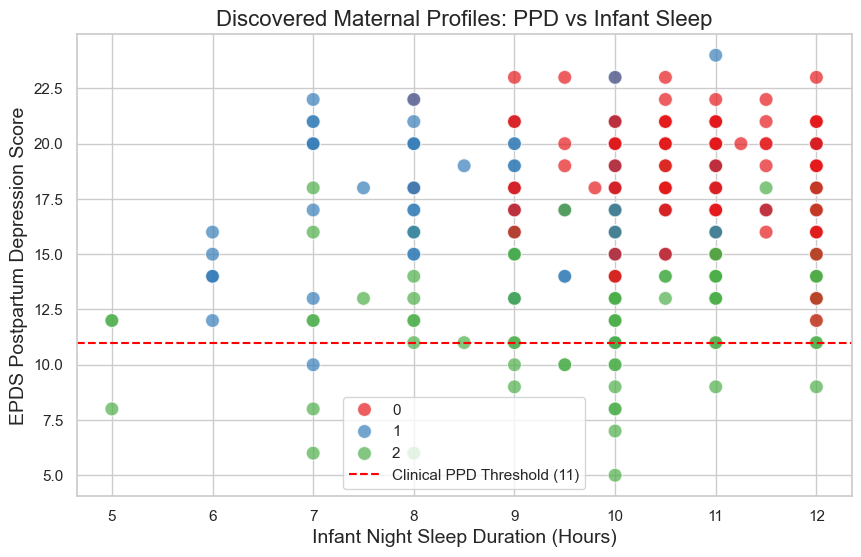

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster, 
    x='sleep_night_duration_bb1', 
    y='epds_total', 
    hue='Profile_Cluster', 
    palette='Set1', 
    alpha=0.7,
    s=100
)

# Plot formatting
plt.title('Discovered Maternal Profiles: PPD vs Infant Sleep', fontsize=16)
plt.xlabel('Infant Night Sleep Duration (Hours)', fontsize=14)
plt.ylabel('EPDS Postpartum Depression Score', fontsize=14)

# Draw the clinical danger line for PPD (Score >= 11)
plt.axhline(11, color='red', linestyle='--', label='Clinical PPD Threshold (11)')
plt.legend()
plt.show()

### 3. Understanding the Clusters
What actually defines these mothers mathematically? We group the dataframe by the new `Profile_Cluster` label and calculate the average score for each feature.

In [4]:
cluster_summary = df_cluster.groupby('Profile_Cluster')[cluster_features].mean().round(2)
display(cluster_summary)

,sleep_night_duration_bb1,night_awakening_number_bb1,epds_total,hads_a_total,cbts_total
Profile_Cluster,,,,,
0,10.85,0.68,18.79,5.60,7.14
1,9.11,3.00,17.62,6.81,9.73
2,9.92,1.43,13.26,12.61,26.46
